In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import sparse

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300,
    fontsize=14,
    format="pdf",
    facecolor="none"
)

In [2]:
adata = sc.read_h5ad('all.clean.raw.h5ad')

In [4]:
X = adata.X
if sparse.issparse(X):
    non_zero_values = X.data[:20]
else:
    non_zero_values = X[X != 0].ravel()[:20]
print("first 20 non-zero values:", non_zero_values)

first 20 non-zero values: [ 5.  2.  8.  2.  6.  7.  5.  9. 22.  5.  3.  1.  9.  1.  1.  1.  1.  1.
  8.  1.]


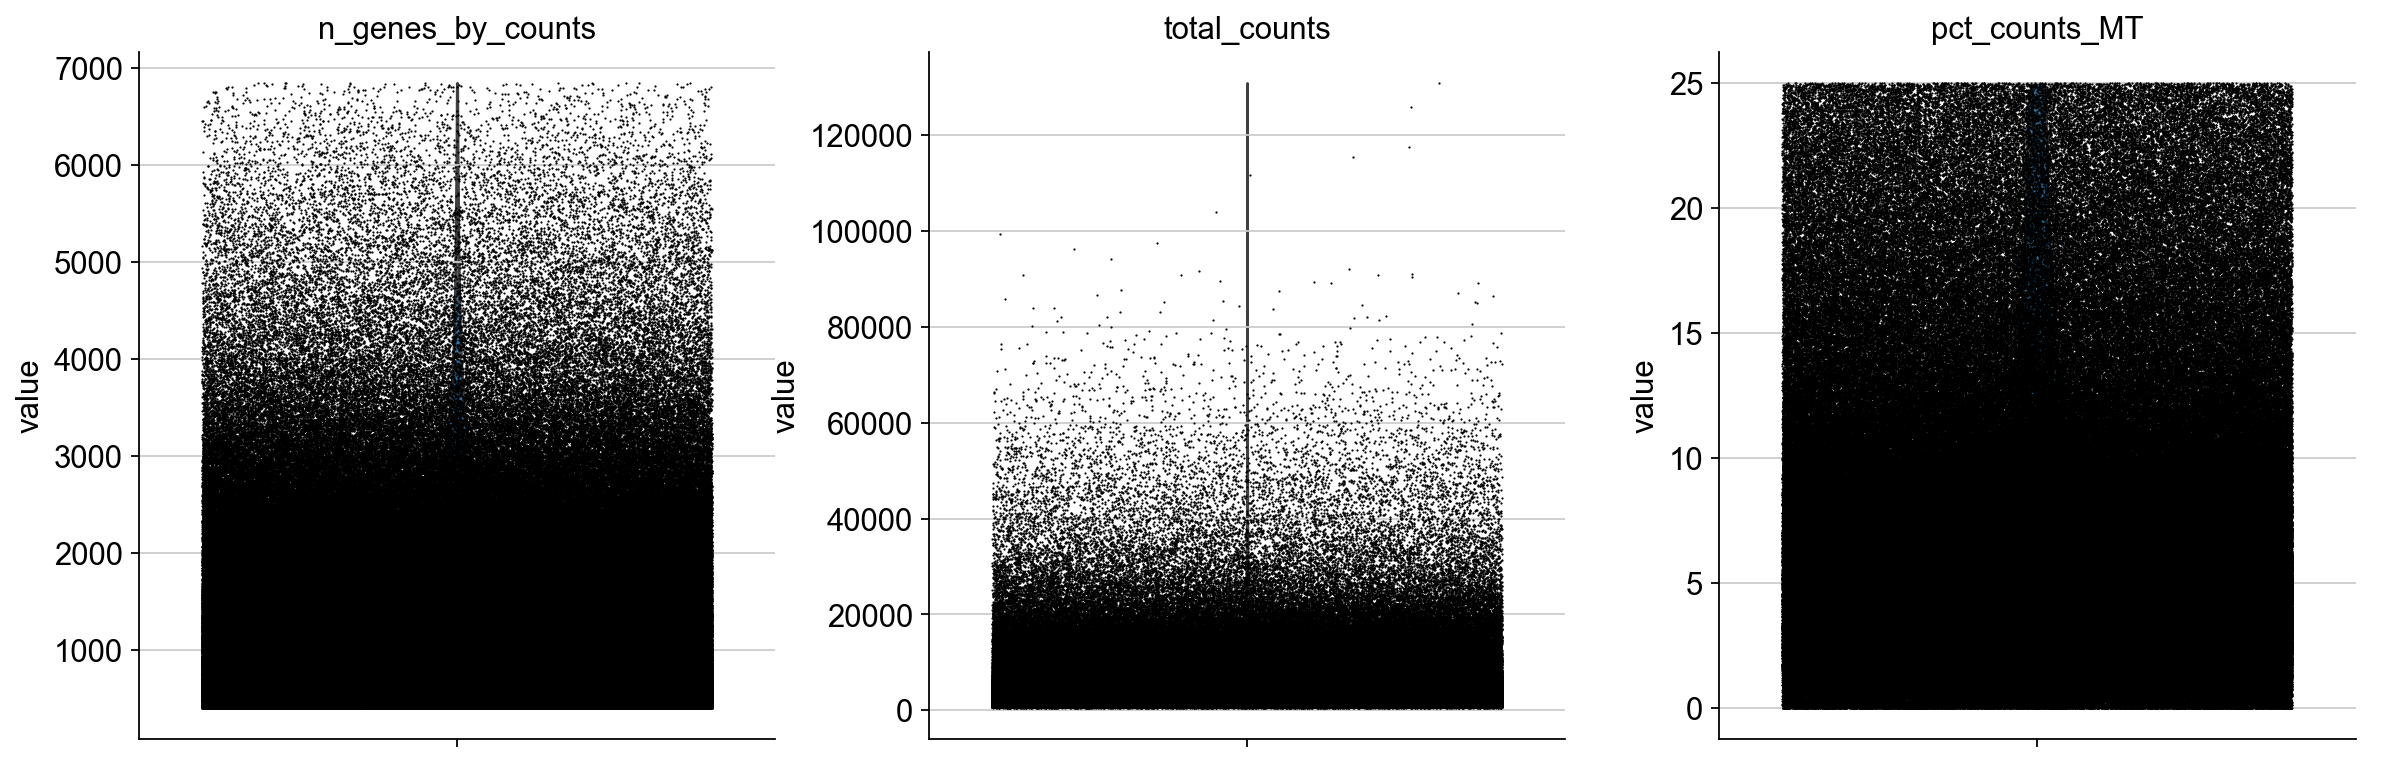

In [5]:
adata.var["MT"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["MT"],
    percent_top=None,
    log1p=False,
    inplace=True
)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_MT"],
    jitter=0.4,
    multi_panel=True
)

In [6]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[
    (adata.obs["n_genes_by_counts"] < 6000) &
    (adata.obs["total_counts"] < 60000) &
    (adata.obs["pct_counts_MT"] < 20)
].copy()

filtered out 88617 cells that have less than 500 genes expressed


In [7]:
adata = adata[
    (adata.obs["stage"] == "adult") &
    (adata.obs["disease"].isin(["CD_non_inflamed", "Healthy", "UC_non_inflamed"])) &
    (adata.obs["major_cluster"].isin(["Myeloid", "CD4T", "CD8T", "ILC", "B_Plasma"]))
].copy()

In [8]:
adata.obs["minor_cluster"] = adata.obs["minor_cluster"].cat.add_categories(["ILC3"])

adata.obs.loc[
    adata.obs["minor_cluster"].isin(["NCR- ILC3", "NCR+ ILC3"]),
    "minor_cluster"
] = "ILC3"

adata.obs["minor_cluster"] = adata.obs["minor_cluster"].cat.remove_unused_categories()

In [9]:
major_map = {
    "CD4T": "CD4+T",
    "CD8T": "CD8+T"
}
minor_map = {
    "Non-classical monocyte": "Monocyte",
    "Classical monocyte": "Monocyte",
    "Inflammatory monocyte": "Monocyte",

    "cDC1": "cDCs",
    "cDC2": "cDCs",

    "pDC": "pDCs",

    "APOE+ macrophage": "Macrophage",
    "LYVE1+ macrophage": "Macrophage",
    "AREG+ macrophage": "Macrophage",
    "Cycling macrophage": "Macrophage",

    "Mast": "Mast",

    "CD16+ NK": "NK",
    "CD56+ SELL_high NK": "NK",
    "CD56+ SELL_low NK": "NK",

    "IgA plasma": "Plasma",
    "IgG plasma": "Plasma",
    "IgA+IgG+ plasma": "Plasma",
    "IgA-IgG- plasma": "Plasma",

    "Naive B": "B",
    "Memory B": "B",

    "GC B": "GC B",

    "ILC3": "ILC3"
}
adata.obs["celltype"] = (
    adata.obs["major_cluster"].map(major_map)
    .fillna(adata.obs["minor_cluster"].map(minor_map))
)

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


c:\Users\wangqiang\anaconda3\envs\scanpy\lib\site-packages\scanpy\plotting\_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


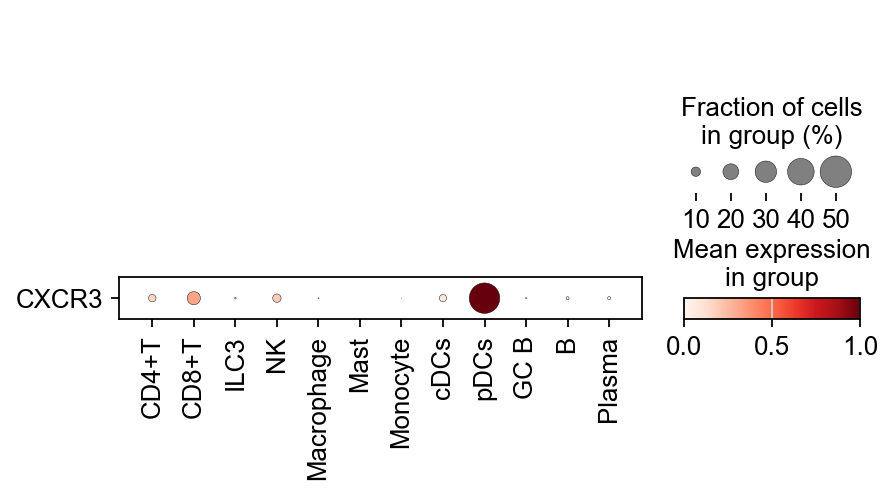

In [11]:
cell_order = [
    'CD4+T',
    'CD8+T',
    'ILC3',
    'NK',
    'Macrophage',
    'Mast',
    'Monocyte',
    'cDCs',
    'pDCs',
    'GC B',
    'B',
    'Plasma',
]
dotplot = sc.pl.dotplot(adata, ['CXCR3'], groupby='celltype', 
                        categories_order=cell_order,
                        swap_axes=True, var_group_rotation=45,
                       standard_scale='var',save="_CXCR3_imm.pdf"
                        )